In [1]:
import os
import collections
import re
from d2l import torch as d2l
from collections import defaultdict, Counter

os.chdir("../") 
from Subwords.Subwords_Vocab import Vocab as Vocab
from Subwords.Subwords_Vocab import load_corpus_time_machine as load_corpus_time_machine



In [5]:
import torch.nn as nn
import torch


In [2]:
corpus, vocab = load_corpus_time_machine(-1, 1000)

BPE训练进度: |█████████████████████████████-| 999/1000
 956


In [10]:
class CBOW(nn.Module):
    def __init__(self, vocab_size, embed_size, window_size=2):
        super(CBOW, self).__init__()
        self.vocab_size = vocab_size
        self.embed_size = embed_size
        self.window_size = window_size  # 上下文窗口大小，设为可配置
        
        # 核心：用nn.Embedding替代One-hot+Linear，效率更高
        self.embedding = nn.Embedding(vocab_size, embed_size)
        # 输出层：将平均后的上下文向量映射到词汇表大小
        self.fc = nn.Linear(embed_size, vocab_size, bias=False)
        
        # 初始化权重（可选，让训练更稳定）
        nn.init.xavier_uniform_(self.embedding.weight)
        nn.init.xavier_uniform_(self.fc.weight)

    def forward(self, context_indices):
        """
        CBOW前向传播：输入上下文索引 → 输出中心词预测概率
        :param context_indices: 形状 [batch_size, 2*window_size]（上下文索引）
        :return: 形状 [batch_size, vocab_size]（中心词预测logits）
        """
        # 1. 取出上下文词的嵌入向量：[batch_size, 2*window_size, embed_size]
        embed = self.embedding(context_indices)
        # 2. 对上下文向量求平均：[batch_size, embed_size]
        embed_avg = torch.mean(embed, dim=1)
        # 3. 预测中心词：[batch_size, vocab_size]
        logits = self.fc(embed_avg)
        return logits

    def get_embedding(self, idx):
        """单独获取词嵌入向量的方法（替代你原来错误的forward）"""
        # idx: 形状 [batch_size, seq_len] 的索引
        return self.embedding(idx)

    def Dataloader(self, corpus, vocab, batch_size):
        """生成训练数据：上下文+中心词"""
        contexts, targets = [], []
        # 遍历语料，生成上下文-中心词对
        for i in range(self.window_size, len(corpus) - self.window_size):
            # 上下文：左右各window_size个词
            context = corpus[i - self.window_size:i] + corpus[i + 1:i + self.window_size + 1]
            target = corpus[i]
            contexts.append(context)
            targets.append(target)
        
        # 转换为tensor（无需One-hot，直接用索引）
        contexts = torch.tensor(contexts, dtype=torch.long)
        targets = torch.tensor(targets, dtype=torch.long)
        
        dataset = torch.utils.data.TensorDataset(contexts, targets)
        return torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    def train_epoch(self, dataloader, loss_fn, optimizer, device):
        """单轮训练"""
        self.train()
        total_loss = 0.0
        for X, Y in dataloader:
            X, Y = X.to(device), Y.to(device)
            
            # 前向传播
            y_hat = self.forward(X)
            loss = loss_fn(y_hat, Y)
            
            # 反向传播
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        # 返回平均loss
        return total_loss / len(dataloader)

    def train_epochs(self, corpus, vocab, lr, num_epochs):
        """多轮训练主函数"""
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.to(device)
        
        # 数据加载
        dataloader = self.Dataloader(corpus, vocab, batch_size=512)
        
        # 损失函数和优化器
        loss_fn = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        
        # 训练记录
        history = []
        for epoch in range(num_epochs):
            avg_loss = self.train_epoch(dataloader, loss_fn, optimizer, device)
            history.append(avg_loss)
            
            # 打印日志
            if (epoch + 1) % 10 == 0 or epoch == 0:
                print(f"epoch {epoch + 1}/{num_epochs}, loss {avg_loss:.4f}")
        
        return history

BPE训练进度: |█████████████████████████████-| 999/1000
 956
epoch 1/100, loss 6.9040
epoch 10/100, loss 5.5078
epoch 20/100, loss 1.6575
epoch 30/100, loss 1.1314
epoch 40/100, loss 0.8396
epoch 50/100, loss 0.6173
epoch 60/100, loss 0.4830
epoch 70/100, loss 0.4225
epoch 80/100, loss 0.3975
epoch 90/100, loss 0.3864
epoch 100/100, loss 0.3808
嵌入矩阵形状: torch.Size([1001, 100])
词嵌入输出形状: torch.Size([2, 4, 100])
第一个词的嵌入向量前5维: tensor([ 0.0664,  0.0111, -0.0392, -0.0300,  0.0710], device='cuda:0',
       grad_fn=<SliceBackward0>)


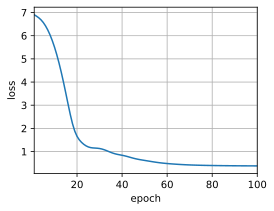

In [13]:
copurs, vocab = load_corpus_time_machine(-1, 1000)

# 初始化模型
test = CBOW(len(vocab), embed_size=100, window_size=2)

# 训练
history = test.train_epochs(corpus, vocab, lr=0.01, num_epochs=100)
d2l.plot(list(range(1, len(history) + 1)), history, xlabel='epoch', ylabel='loss', xlim=[1, len(history)], figsize=(4, 3))
# 查看嵌入矩阵形状（vocab_size, embed_size）
print("嵌入矩阵形状:", test.embedding.weight.shape)

# 测试获取词嵌入向量
test_X = torch.tensor([[0, 1, 2, 3], [4, 5, 6, 7]], dtype=torch.long)
embed_vec = test.get_embedding(test_X.to(test.embedding.weight.device))
print("词嵌入输出形状:", embed_vec.shape)  # [2,4,100]
print("第一个词的嵌入向量前5维:", embed_vec[0, 0][:5])

In [16]:
tt = torch.tensor([1e-100] * 4)
print(torch.softmax(tt, dim=0))

tensor([0.2500, 0.2500, 0.2500, 0.2500])
